一開始做：
1. 數據增強
2. 訓練集/驗證集切割


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 定義本地端資料路徑
DATASET_PATH = './dataset/train'  # 請確保這個資料夾存在，且裡面有三個子資料夾

# 建立資料增強產生器
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    # 🔥 大幅調整以下兩行：模擬隨機光線與雜訊干擾
    brightness_range=[0.4, 1.6],     # 讓光線從極暗到極亮
    channel_shift_range=0.2,         # 新增：強行改變像素數值，製造隨機雜訊感
    shear_range=0.15,
    validation_split=0.2
)

# 載入訓練集
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(96, 96),
    color_mode='grayscale',  # 降灰階 1 Channel
    batch_size=32,
    class_mode='sparse',     # 自動生成 0, 1, 2 標籤
    subset='training',
    shuffle=True
)

# 載入驗證集
validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(96, 96),
    color_mode='grayscale',
    batch_size=32,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

# 印出本地端 Keras 自動排序的正確字典（重要，對齊標籤！）
labels_map = {v: k for k, v in train_generator.class_indices.items()}
print("\n[系統對齊成功] 本地端類別索引為：", labels_map)

Found 2175 images belonging to 3 classes.
Found 542 images belonging to 3 classes.

[系統對齊成功] 本地端類別索引為： {0: 'paper', 1: 'rock', 2: 'scissors'}


這裡用Tensorflow做為框架, 要把模型縮小成TensorflowLite, 用於放在


🚀 本地端 AI 大腦開始訓練...
Epoch 1/30
68/68 [==============================] - 11s 149ms/step - loss: 1.1200 - accuracy: 0.3467 - val_loss: 1.0970 - val_accuracy: 0.4004 - lr: 0.0010
Epoch 2/30
68/68 [==============================] - 8s 122ms/step - loss: 1.0989 - accuracy: 0.3462 - val_loss: 1.0876 - val_accuracy: 0.3893 - lr: 0.0010
Epoch 3/30
68/68 [==============================] - 8s 119ms/step - loss: 1.0838 - accuracy: 0.4069 - val_loss: 1.0554 - val_accuracy: 0.5572 - lr: 0.0010
Epoch 4/30
68/68 [==============================] - 8s 119ms/step - loss: 1.0403 - accuracy: 0.4772 - val_loss: 0.9943 - val_accuracy: 0.4834 - lr: 0.0010
Epoch 5/30
68/68 [==============================] - 8s 121ms/step - loss: 0.9972 - accuracy: 0.5186 - val_loss: 0.9233 - val_accuracy: 0.5590 - lr: 0.0010
Epoch 6/30
68/68 [==============================] - 8s 117ms/step - loss: 0.9618 - accuracy: 0.5448 - val_loss: 0.9444 - val_accuracy: 0.5554 - lr: 0.0010
Epoch 7/30
68/68 [==============================]

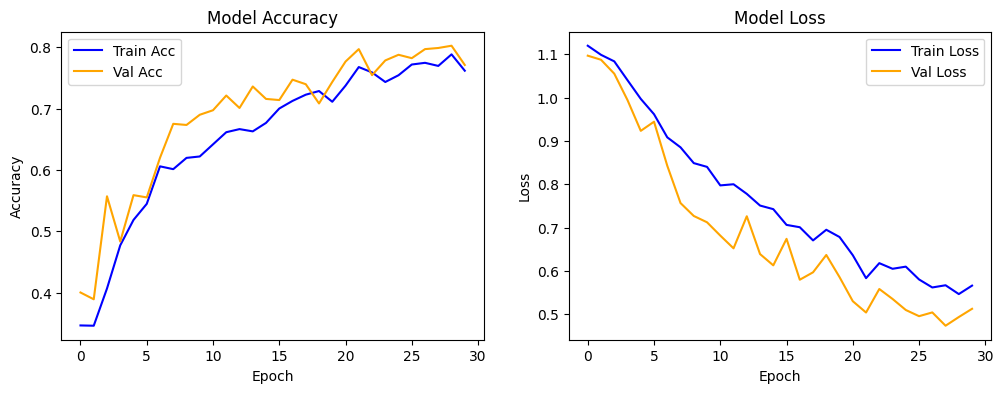

In [3]:
from keras import layers, models
from keras.callbacks import ReduceLROnPlateau


model = models.Sequential([
    layers.Input(shape=(96, 96, 1)),
    
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 🔥 新增第三層：抓複雜的手勢整體輪廓 (64個濾鏡)
    # layers.Conv2D(64, (3, 3), activation='relu'),
    # layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dropout(0.5), # 隨機丟棄 50% 神經元，抗過擬合
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 本地端 AI 大腦開始訓練...")
# 設定監聽器：如果 val_loss 連續 3 輪沒降，就將學習率乘以 0.5
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    verbose=1, 
    min_lr=1e-6
)

# 在 fit 的時候把 callbacks 傳進去
history = model.fit(
    train_generator, 
    epochs=30, # 既然有了學習率衰減，大膽調到 35 輪讓它收斂
    validation_data=validation_generator,
    callbacks=[lr_reducer] # 🔥 啟動監聽器
)
print("🎉 訓練完成！")


# ==========================================
# 📊 【第一層驗證：學習曲線 (Learning Curves)】
# ==========================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 94, 94, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 47, 47, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 45, 45, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 22, 22, 32)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 15488)             0         
                                                                 
 dropout (Dropout)           (None, 15488)             0

In [8]:
# 把你記憶體中的模型，存成電腦裡的實體檔案
model.save('rps.h5')
print("模型存檔成功！")


模型存檔成功！


In [6]:
import cv2
import numpy as np

# 1. 啟動鏡頭
cap = cv2.VideoCapture(0)
labels_map = {0: 'paper', 1: 'rock', 2: 'scissors'}

print("🚀 啟動【背景自動塗白】即時偵測！")
print("💡 請將手靠近鏡頭一點，讓手成為畫面中最大的膚色物體。按下 'q' 退出。")

while True:
    ret, frame = cap.read()
    if not ret or frame is None:
        break
        
    # 複製一份原始畫面用來畫圖
    display_frame = frame.copy()
    h_img, w_img, _ = frame.shape
    
    # ─── 步驟一：利用膚色偵測抓出手的範圍 ───
    # 將 BGR 轉換到 YCrCb 顏色空間（對膚色極度敏感且抗光線干擾）
    y_cr_cb = cv2.cvtColor(frame, cv2.COLOR_BGR2YCrCb)
    
    # 膚色在 YCrCb 中的標準數學區間
    min_ycrcb = np.array([0, 133, 77], np.uint8)
    max_ycrcb = np.array([255, 173, 127], np.uint8)
    
    # 建立膚色遮罩（手的部分是 255 純白，背景是 0 純黑）
    skin_mask = cv2.inRange(y_cr_cb, min_ycrcb, max_ycrcb)
    
    # 形態學濾波：消除背景微小的膚色雜訊點
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    skin_mask = cv2.erode(skin_mask, kernel, iterations=1)
    skin_mask = cv2.dilate(skin_mask, kernel, iterations=2)
    skin_mask = cv2.GaussianBlur(skin_mask, (3, 3), 0)
    
    # ─── 步驟二：尋找最大輪廓，排除背景其他膚色干擾 ───
    contours, _ = cv2.findContours(skin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 建立一個與原圖一樣大、但預填「全純白」的畫布
    white_background_frame = np.ones_like(frame) * 255
    
    if len(contours) > 0:
        # 抓出畫面中面積最大的輪廓（理論上就是你的手掌）
        max_contour = max(contours, key=cv2.contourArea)
        
        # 如果這個最大輪廓的面積夠大（不是小雜訊），我們才處理
        if cv2.contourArea(max_contour) > 2000:
            # 建立一個黑色的遮罩畫布
            hand_mask = np.zeros((h_img, w_img), dtype=np.uint8)
            # 在黑畫布上，把最大輪廓內部填滿純白 (255)
            cv2.drawContours(hand_mask, [max_contour], -1, 255, thickness=cv2.FILLED)
            
            # 把原圖中屬於手的部分（hand_mask == 255）拷貝到純白畫布上
            white_background_frame[hand_mask == 255] = frame[hand_mask == 255]
            
            # 在顯示畫面上順便畫出綠色輪廓，方便你確認有沒有抓準
            cv2.drawContours(display_frame, [max_contour], -1, (0, 255, 0), 2)

    # ─── 步驟三：將這張「已被去背景、塞滿純白」的圖做灰階前處理，餵給 AI ───
    gray_white_bg = cv2.cvtColor(white_background_frame, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray_white_bg, (96, 96))
    normalized = resized / 255.0
    input_tensor = np.expand_dims(np.expand_dims(normalized, axis=0), axis=-1)
    
    # AI 預測
    pred = model.predict(input_tensor, verbose=0)
    pred_class_name = labels_map[np.argmax(pred)]
    confidence = np.max(pred) * 100
    
    # ─── 步驟四：畫面秀出來 ───
    text = f"Predict: {pred_class_name} ({confidence:.1f}%)"
    cv2.putText(display_frame, text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    cv2.imshow('1. Original Camera (with Green Contour)', display_frame)
    cv2.imshow('2. What AI Sees (96x96 Input)', resized) # 這視窗會顯示它是不是成功變成了純白背景的手
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

🚀 啟動【背景自動塗白】即時偵測！
💡 請將手靠近鏡頭一點，讓手成為畫面中最大的膚色物體。按下 'q' 退出。


In [7]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)
labels_map = {0: 'paper', 1: 'rock', 2: 'scissors'}

print("🚀 啟動【防人頭干擾 + 背景塗白】即時偵測！")

while True:
    ret, frame = cap.read()
    if not ret or frame is None:
        break
        
    display_frame = frame.copy()
    h_img, w_img, _ = frame.shape
    
    # ─── 核心修改 1：設定一個「綠色偵測框」 ───
    # 假設鏡頭 640x480，我們在正中央畫一個 350x350 的框框
    # 這樣你的頭在框框外面，就絕對不會被當成手！
    box_w, box_h = 350, 350
    x1 = int((w_img - box_w) / 2)
    y1 = int((h_img - box_h) / 2)
    x2, y2 = x1 + box_w, y1 + box_h
    
    # 在畫面上畫出偵測區域
    cv2.rectangle(display_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(display_frame, "PUT HAND HERE", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    # 只把框框內的影像切出來做膚色偵測 (ROI)
    roi = frame[y1:y2, x1:x2]
    
    # ─── 步驟一：膚色偵測 (只針對框框內) ───
    y_cr_cb = cv2.cvtColor(roi, cv2.COLOR_BGR2YCrCb)
    min_ycrcb = np.array([0, 133, 77], np.uint8)
    max_ycrcb = np.array([255, 173, 127], np.uint8)
    skin_mask = cv2.inRange(y_cr_cb, min_ycrcb, max_ycrcb)
    
    # 形態學濾波
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    skin_mask = cv2.erode(skin_mask, kernel, iterations=1)
    skin_mask = cv2.dilate(skin_mask, kernel, iterations=2)
    
    # ─── 步驟二：尋找最大輪廓 ───
    contours, _ = cv2.findContours(skin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 建立一個與 ROI 一樣大、預填「全純白」的畫布
    white_roi = np.ones_like(roi) * 255
    
    if len(contours) > 0:
        max_contour = max(contours, key=cv2.contourArea)
        
        # ─── 核心修改 2：幾何特徵過濾 ───
        area = cv2.contourArea(max_contour)
        if area > 1500: # 框框變小了，面積閾值也可以調小一點
            # 計算輪廓的外接矩形
            rx, ry, rw, rh = cv2.boundingRect(max_contour)
            aspect_ratio = float(rw) / rh  # 長寬比
            
            # 手掌伸直或剪刀通常比較有方向性，如果太像正方形（如 1.0），可能要小心
            # 這裡我們主要靠 ROI 框框擋掉人頭，所以只要面積對，就進行塗白
            hand_mask = np.zeros((box_h, box_w), dtype=np.uint8)
            cv2.drawContours(hand_mask, [max_contour], -1, 255, thickness=cv2.FILLED)
            
            # 把手複製到純白畫布
            white_roi[hand_mask == 255] = roi[hand_mask == 255]
            
            # 在顯示畫面上把綠色輪廓畫出來（要加上 offset 修正位置）
            cv2.drawContours(display_frame[y1:y2, x1:x2], [max_contour], -1, (0, 255, 0), 2)

    # ─── 步驟三：將這張純白背景的 ROI 餵給 AI ───
    gray_white_bg = cv2.cvtColor(white_roi, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray_white_bg, (96, 96))
    normalized = resized / 255.0
    input_tensor = np.expand_dims(np.expand_dims(normalized, axis=0), axis=-1)
    
    # AI 預測
    pred = model.predict(input_tensor, verbose=0)
    pred_class_name = labels_map[np.argmax(pred)]
    confidence = np.max(pred) * 100
    
    # ─── 步驟四：顯示畫面 ───
    text = f"Predict: {pred_class_name} ({confidence:.1f}%)"
    cv2.putText(display_frame, text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    cv2.imshow('1. Camera View', display_frame)
    cv2.imshow('2. What AI Sees (ROI Input)', resized) 
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

🚀 啟動【防人頭干擾 + 背景塗白】即時偵測！


In [9]:
import tensorflow as tf
import numpy as np

# 1. 載入你剛剛存好的模型
model = tf.keras.models.load_model('rps.h5')

# 2. 代表性資料集（請用你真實訓練用的 train_generator 丟進去最準確）
# 這裡建立一個簡單的產生器，確保資料範圍與你訓練時相同
def representative_data_gen():
    # 建議直接從你的 train_generator 取樣
    # 如果 train_generator 還在記憶體中，可以直接這樣寫：
    try:
        for i in range(100):
            # 每次拿一組資料 (batch)，並只取影像部分 [0]
            xs, ys = next(train_generator)
            # 確保只餵一張圖進去轉換器 (1, 96, 96, 1)
            yield [xs[0:1]]
    except NameError:
        # 如果 train_generator 已經釋放，則用模擬數據對齊（影像有除以 255.0，範圍 0~1）
        for _ in range(100):
            data = np.random.rand(1, 96, 96, 1).astype(np.float32)
            yield [data]

# 3. 初始化轉換器
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# 4. 【修正這裡】TensorFlow 2.11.0 支援的標準 INT8 算子限制寫法
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8] # 改成 TFLITE_BUILTIN 即可
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# converter.inference_input_type = tf.float32
# converter.inference_output_type = tf.uint8

# 5. 執行轉換並導出
tflite_quant_model = converter.convert()
with open('model_quant_esp32.tflite', 'wb') as f:
    f.write(tflite_quant_model)

print("🎉 恭喜！ESP32 專用 INT8 量化模型（model_quant_esp32.tflite）導出成功！")

INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmpvyv3c55j\assets


INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmpvyv3c55j\assets
c:\Users\james\anaconda3\envs\edge_ai\lib\site-packages\tensorflow\lite\python\convert.py:765: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


🎉 恭喜！ESP32 專用 INT8 量化模型（model_quant_esp32.tflite）導出成功！


這裡是要把tf轉.h就是c看得懂語言 ， 這部叫量化

In [10]:
# 讀取剛剛成功生成的 tflite 模型
with open('model_quant_esp32.tflite', 'rb') as f:
    tflite_content = f.read()

# 將二進位檔案轉換成十六進位字串格式 (例如: 0x1c, 0x00...)
hex_lines = [f"0x{b:02x}" for b in tflite_content]

# 寫出成 C 語言標頭檔 model_data.h
with open('model_data.h', 'w', encoding='utf-8') as f:
    f.write('#ifndef MODEL_DATA_H\n#define MODEL_DATA_H\n\n')
    f.write('// 這是專門給 ESP32 TensorFlow Lite 讀取的 INT8 量化模型陣列\n')
    f.write(f'const unsigned char g_model[] = {{\n')
    
    # 每 12 個十六進位數字換一行，格式化看起來比較整齊
    for i in range(0, len(hex_lines), 12):
        f.write("  " + ", ".join(hex_lines[i:i+12]) + ",\n")
        
    f.write(f'}};\n\n')
    f.write(f'const unsigned int g_model_len = {len(tflite_content)};\n\n')
    f.write('#endif // MODEL_DATA_H\n')

print("🎉 恭喜！model_data.h 檔案生成成功！")
print(f"模型陣列大小：{len(tflite_content)} 位元組 (Bytes)")

🎉 恭喜！model_data.h 檔案生成成功！
模型陣列大小：1001736 位元組 (Bytes)


: 